  # Perkenalan

Notebook ini dibuat oleh Ghaffar Farros sebagai salah satu portfolio Data Analysis, untuk melakukan penerapan rangkaian proses data analisis untuk mengetahui berbagai insight dari dataset yang dipilih berdasarkan metode, metrik, menarik kesimpulan dan memberikan rekomendasi. Hasil akhir nantinya akan divisualisasikan dengan Tableau Public secara interaktif agar mudah dipahami.

# Identifikasi Masalah

## Latar Belakang
Perusahaan saat ini tengah melaksanakan evaluasi terhadap hasil dari berbagai online campaign yang telah dijalankan sebelumnya. Tujuan utama dari evaluasi ini adalah untuk menggali wawasan yang dapat diambil dari data yang ada. Insight yang diperoleh nantinya akan menjadi dasar dalam pengambilan keputusan strategis untuk arah dan perbaikan kampanye online di masa mendatang, dengan harapan dapat mencapai target profit yang diinginkan dalam beberapa bulan ke depan. Evaluasi ini akan difokuskan pada upaya peningkatan nilai-nilai metrik yang digunakan untuk menilai keberhasilan setiap kampanye, sehingga hasil yang diperoleh dapat lebih optimal dan mengalami perkembangan yang berkelanjutan.

## Problem Statement

Secara spesifik, project ini ditujukan untuk meningkatkan efektivitas dan efisiensi campaign, dengan meningkatkan jumlah Click dan Conversion Rate. Untuk mengukur keberhasilan project, diproyeksikan nantinya dapat meningkatkan 20% dari jumlah klik dan 10% Conversion Rate. Dengan optimasi anggaran dan penentuan saluran promosi yang tepat, project memiliki tujuan yang achievable dengan rentang waktu yang ada. Tujuan ini penting mengingat peningkatan jumlah klik merupakan salahs atu faktor penting pada Conversion Funnel, sehingga akan berdampak pada pendapatan. Ketika jumlah klik dan Conversion Rate meningkat, hal ini dapat mendukung pencapaian target perusahaan. Selain itu, evaluasi juga dilakukan secara berkala untuk memastikan progress dan melakukan penyesuaian yang diperlukan. Dengan rentang waktu 3 bulan yang diiringi dengan evalusasi secara berkala, project ini diharapkan menunjukkan hasil yang signifikan.

## Problem Breakdown
- Kategori dan campaign apa saja yang berjalan saat ini dan berapa persentasenya di bulan ini?
- Bagaimana tren rata-rata impression dan clicks berdasarkan time frame? 
- Kategori campaign mana dengan revenue paling besar?
- Kategori campaign mana yang biayanya paling mahal?
- Apakah semakin besar biaya dikeluarkan, maka semakin besar jumlah pesanan?

# Import Library

In [57]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Data Extract

In [58]:
# Download data dari kaggle dengan menggunakan kaggle API
!kaggle datasets download sinderpreet/analyze-the-marketing-spending --unzip

Dataset URL: https://www.kaggle.com/datasets/sinderpreet/analyze-the-marketing-spending
License(s): CC0-1.0




  0%|          | 0.00/7.44k [00:00<?, ?B/s]
100%|██████████| 7.44k/7.44k [00:00<00:00, 1.13MB/s]


In [59]:
# Read CSV dengan pandas
DF = pd.read_csv('Marketing.csv')
DF

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0
...,...,...,...,...,...,...,...,...,...,...,...
303,304,2021-02-28,instagram_tier2,social,983498,775780,760.75,1024,4,0,0.0
304,305,2021-02-28,facebook_retargeting,social,4387490,1933,224.81,58,0,0,0.0
305,306,2021-02-28,facebook_lal,social,544756,25840,6844.80,248,5,1,1491.0
306,307,2021-02-28,instagram_blogger,influencer,374754,94058,4845.65,594,12,1,5008.0


Berikut menampilkan dataframe-nya. Terdapat 11 kolom yaitu:
- id            = setiap campaign yang bersifat unique setiap rownya
- c_date        = campaign date, tanggal campaign dijalankan
- campaign_name = nama campaign yang dijalankan sesuai platformnya
- category      = kategori campaign dijalankan
- campaign_id   = nama id campaign
- impressions   = jumlah tayangan iklan yang dilihat audiens
- mark_spent    = biaya yang dikeluarkan untuk campaign
- clicks        = jumlah campaign yang tayang dibuka/klik oleh audiens
- leads         = audiens yang berpotensi untuk menjadi pelanggan dan memiliki ketertarikan
- orders        = jumlah pesanan yang dilakukan dari iklan
- revenue       = penghasilan yang diperoleh

Pada dataframe ini terdapat 308 baris data yang diperoleh dan berisi data mengenai campaign yang didapat selama 1 bulan pada Februari 2021. 

# Data Cleaning

## Missing Value & Duplicated

In [60]:
DF.info()                                       # cek summary dan info seputar dataframe
print('----------------------------------------------------------------------')
print("Data dengan missing value sebanyak :",DF.isna().sum())        # cek apakah ada data kosong
print('----------------------------------------------------------------------')
print("Row dengan duplikasi sebanyak :", DF.duplicated().sum())  # cek apakah ada duplikasi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             308 non-null    int64  
 1   c_date         308 non-null    object 
 2   campaign_name  308 non-null    object 
 3   category       308 non-null    object 
 4   campaign_id    308 non-null    int64  
 5   impressions    308 non-null    int64  
 6   mark_spent     308 non-null    float64
 7   clicks         308 non-null    int64  
 8   leads          308 non-null    int64  
 9   orders         308 non-null    int64  
 10  revenue        308 non-null    float64
dtypes: float64(2), int64(6), object(3)
memory usage: 26.6+ KB
----------------------------------------------------------------------
Data dengan missing value sebanyak : id               0
c_date           0
campaign_name    0
category         0
campaign_id      0
impressions      0
mark_spent       0
clicks           0


Dari informasi diatas dapat dilihat bahwa sebagian besar data type sudah sesuai, kecuali pada kolom `c_date` yang menunjukkan tanggal, serta tidak terdapat data kosong.

## Data Type

In [61]:
DF['c_date'] = pd.to_datetime(DF['c_date'])             # Mengubah tipe data kolom c_date menjadi datetime
DF['campaign_name'] = DF['campaign_name'].str.lower()   # Mengubah semua huruf pada campaign_name menjadi huruf kecil

penyesuaian dilakukan dengan mengubah data type kolom `c_date` ke tanggal, dan untuk keseragaman kolom  `campaign_name` dibuat lowercase

# Data Analisis

## Central tendency, minimal, dan maksimal Revenue

In [62]:
avg = DF['revenue'].mean()
median = DF['revenue'].median()
modus = DF['revenue'].mode()
max = DF['revenue'].max()
min = DF['revenue'].min()

print(f'nilai rata-rata adalah  {avg}')
print(f'nilai median adalah     {median}')
print(f'nilai modus adalah      {modus}')
print(f'nilai max adalah        {max}')
print(f'nilai min adalah        {min}')

nilai rata-rata adalah  139251.1883116883
nilai median adalah     38917.0
nilai modus adalah      0    0.0
Name: revenue, dtype: float64
nilai max adalah        2812520.0
nilai min adalah        0.0


Revenue mewakili pendapatan dan hasil yang dituju perusahaan, dari hasil diketahui rata-rata pendapatannya adalah Rp139,251.18. Nilai tengah berada di Rp38,917 dan paling banyak muncul adalah 0 yang juga merupakan nilai minimal revenue-nya. 

Nilai median yang jauh lebih rendah dari rata-rata menunjukkan adanya distribusi revenue yang tidak merata, artinya sebagian besar hari (lebih dari 50%) menghasilkan revenue yang jauh lebih rendah dibandingkan dengan hari yang menghasilkan revenue lebih tinggi.

## Persentase Campaign

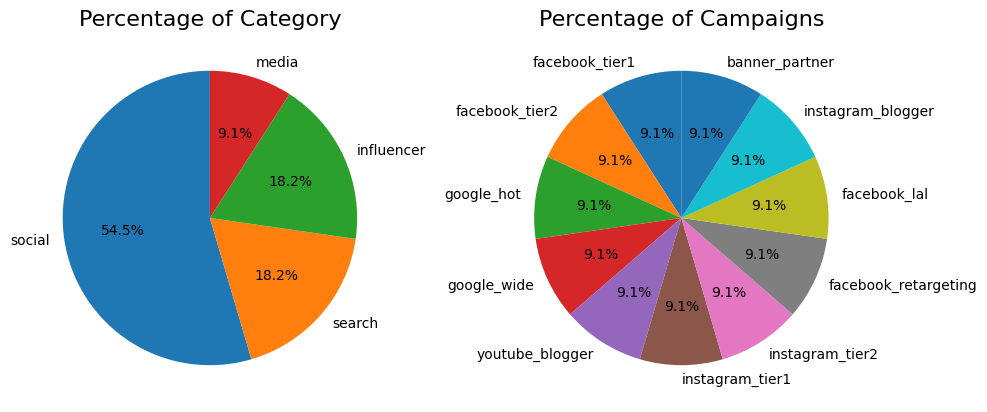

In [63]:
# Proporsi campaign berjalan
category_counts = DF['category'].value_counts()
campaign_counts = DF['campaign_name'].value_counts()

plt.figure(figsize=(10,5))

# Category
plt.subplot(1, 2, 1)
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Category', fontsize=16)

# Campaign
plt.subplot(1, 2, 2)
plt.pie(campaign_counts, labels=campaign_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Campaigns', fontsize=16)

plt.tight_layout()  # Memastikan layout tidak tumpang tindih
plt.show()


Chart diatas menunjukkan persentase promosi yang sedang berlangsung berdasarkan kategori dan jenis campaign-nya. Kategori social media paling besar sebesar 54,5% dan untuk masing-masing nama campaign proporsinya dibagi rata.

## Tren Click dan Impression

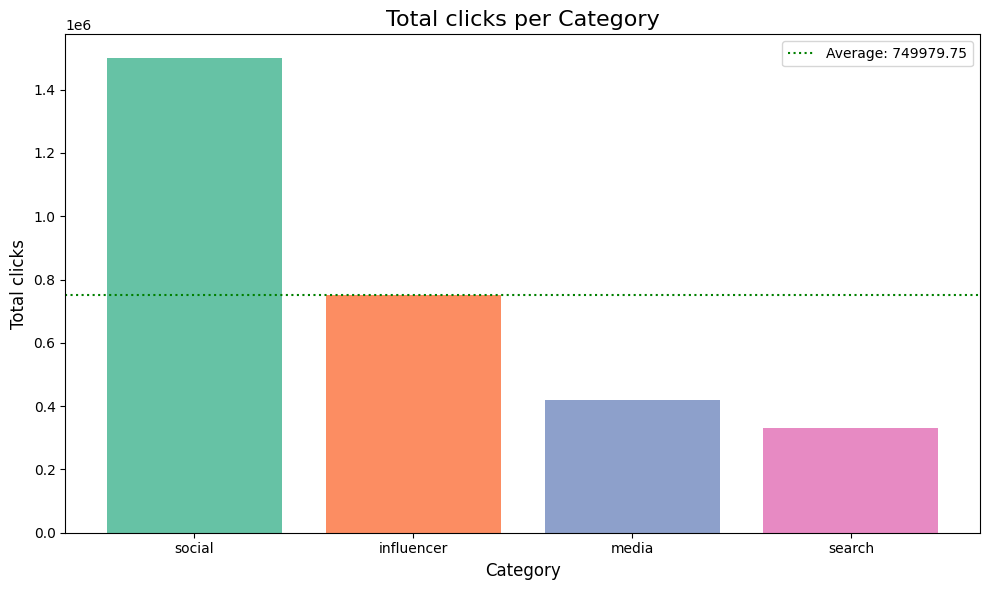

In [64]:
# Data preparation
df_click = DF.groupby('category')['clicks'].sum()
df_click = df_click.sort_values(ascending=False)
avg_r = df_click.mean() 

# Pallette
categories = df_click.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))  # Ensure same palette
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(df_click.index, df_click.values, color=[category_colors[category] for category in df_click.index])
plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total clicks per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total clicks', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


Click terbanyak dimiliki oleh social, influencer, media, dan search engine

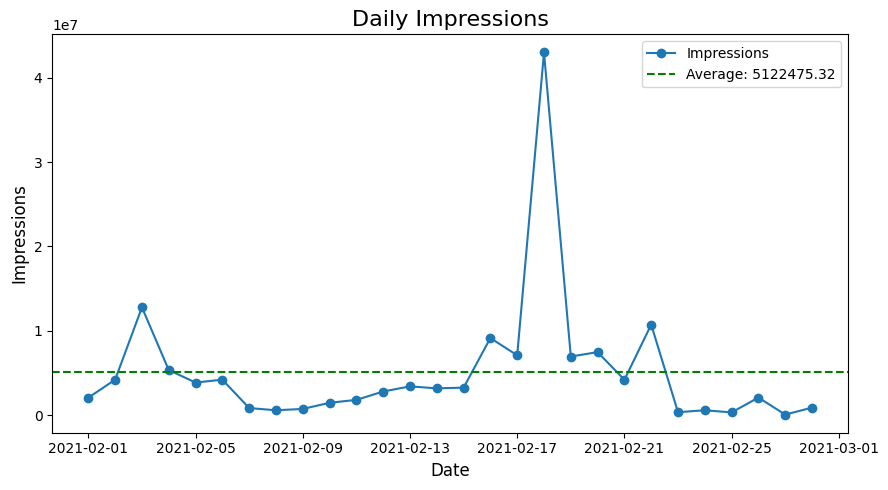

In [65]:
# Data prepare
DT = DF.groupby("c_date")[["impressions", "clicks"]].mean().reset_index()
DT = DT.sort_values('c_date')
avg_imp = DT['impressions'].mean()

# Chart
plt.figure(figsize=(9,5))
plt.plot(DT['c_date'], DT['impressions'], marker='o', label='Impressions')

plt.axhline(y=avg_imp, color='green', linestyle='--', label=f'Average: {avg_imp:.2f}')
plt.title('Daily Impressions', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


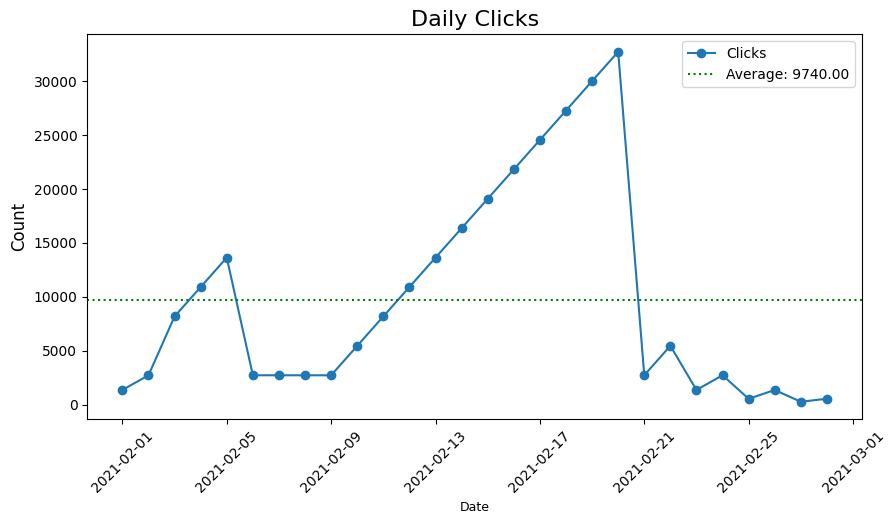

In [66]:
# Data prepare
avg_click = DT['clicks'].mean()

# Chart
plt.figure(figsize=(10,5))
plt.plot(DT['c_date'], DT['clicks'], marker='o', label='Clicks')

plt.axhline(y=avg_click, color='green', linestyle=':', label=f'Average: {avg_click:.2f}')
plt.title('Daily Clicks', fontsize=16)
plt.xlabel('Date', fontsize=9)
plt.ylabel('Count', fontsize=12)
plt.legend()

plt.xticks(rotation=45)
plt.show()

Impressions merupakan metrik yang mengukur jumlah tayangan pada konten yang diiklankan, hal tersebut merupakan pintu pertama dalam sebuah funnel. Diatas nampak line chart total impressions sesuai time frame-nya. Terlihat pada 18 Februari 2021 menunjukkan data impressions yang paling tinggi dibanding lainnya.
Clicks mengukur seberapa banyak iklan tersebut dibuka oleh viewers, dan hasil klik paling tinggi berada pada tanggal 20.

Note: Keduanya tidak ditampilkan berbandingan dalam multiple line chart karena nilai terlalu jauh, sehingga line chart untuk clicks tidak terlihat tren-nya

In [67]:
top_clicks = DF.groupby(['c_date', 'category'])['clicks'].sum().reset_index()
top_clicks = top_clicks.sort_values(by='clicks', ascending=False)

# Ambil top 10 hari dengan klik terbanyak
top_10_days = top_clicks.head(10)
top_10 = top_10_days.sort_values(by='c_date', ascending=False)
top_10

,c_date,category,clicks
79,2021-02-20,social,179972
76,2021-02-20,influencer,89987
75,2021-02-19,social,165019
72,2021-02-19,influencer,82509
71,2021-02-18,social,149985
67,2021-02-17,social,135016
63,2021-02-16,social,119989
59,2021-02-15,social,105006
55,2021-02-14,social,89997
51,2021-02-13,social,75006


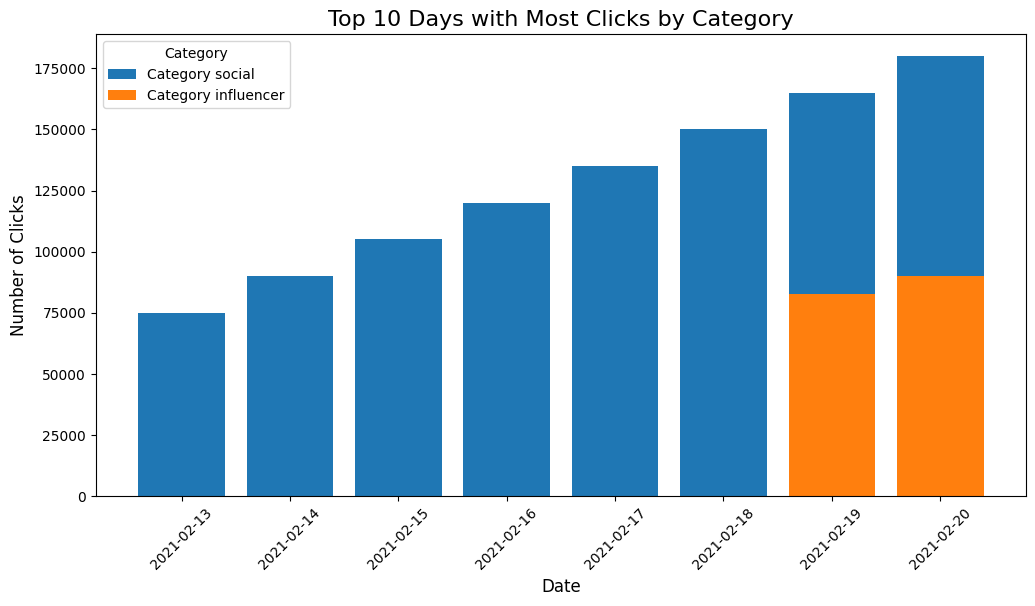

In [68]:
# Visualisasi
plt.figure(figsize=(12, 6))

for category in top_10['category'].unique():
    category_data = top_10[top_10['category'] == category]
    plt.bar(category_data['c_date'], category_data['clicks'], label=f'Category {category}')

plt.title('Top 10 Days with Most Clicks by Category', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Clicks', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')

plt.show()

`- Dominasi Kategori "Social":`   
Kategori "social" mendominasi daftar top 10 clicks dengan jumlah yang jauh lebih tinggi dibandingkan kategori lainnya, menunjukkan bahwa kampanye berbasis media sosial sangat efektif dalam menarik klik.

`- Puncak Clicks:  `  
Pada tanggal 19 dan 20 Februari 2021, dua kategori "social" dan "influencer" mencatatkan jumlah klik tertinggi, menandakan bahwa event atau aktivitas yang sangat menarik pada tanggal tersebut, seperti influencer yang berpengaruh, konten yang efektif, peluncuran produk, atau promosi besar. "Viral" menjadi asumsi yang cocok menggambarkan situasi ini mengingat tren bertahap naik sejak tanggal 9 hingga 20.

`- Tren Peningkatan: `  
Terdapat tren peningkatan klik pada kategori "social" mulai dari 9-20 Februari. Peningkatan ini bisa menunjukkan bahwa audiens semakin terlibat atau tertarik dengan kampanye yang berjalan, atau konten yang sedang viral. Kemudian ada penurunan klik yang cukup signifikan dari 20-21 Februari. Ini bisa menunjukkan bahwa efektivitas kampanye cenderung berfluktuasi, dan analisis lebih lanjut diperlukan untuk mengetahui faktor yang mempengaruhi hal ini (misalnya, konten, atau audiens yang terlibat).

`- Peran Influencer: `  
Meskipun kategori "social" lebih dominan, kategori "influencer" tetap menunjukkan angka yang signifikan, terutama pada tanggal 20 Februari. Hal ini mengindikasikan bahwa kolaborasi dengan influencer yang tepat dapat memberikan dampak positif terhadap tingkat interaksi. Kolaborasi dengan influencer pada waktu yang tepat bisa menjadi strategi tambahan untuk meningkatkan klik lebih lanjut.

`- Peluang Fokus pada Kampanye Social Media: `  
Berdasarkan dominasi kategori "social", mungkin lebih baik untuk memfokuskan anggaran dan sumber daya kampanye lebih banyak pada media sosial untuk memaksimalkan jumlah klik dan keterlibatan.

`- Potensi Hari Spesial atau Event: `   
Mengingat tingginya klik pada beberapa tanggal tertentu (terutama 20 Februari), penting untuk menggali lebih dalam apakah ini berkaitan dengan hari spesial, promosi tertentu, atau event yang menarik perhatian audiens. Strategi kampanye dapat dipertimbangkan berdasarkan hal ini.


---


**Visualisasi diatas menunjukkan hasil dari impression dan clicks, namun apakah click yang banyak berarti efisien dalam penggunaan anggaran? Apakah click yang banyak ternyata menggunakan banyak pengeluaran hingga defisit? Selanjutnya akan dibahas dengan rasio antara pendapatan dan pengeluaran.**

## Cost, Revenue, dan Ratio

In [69]:
DF_unique = DF.drop_duplicates(subset=['category', 'campaign_name'])
DF_unique = DF_unique[['category', 'campaign_name']].sort_values(by='category')
DF_unique

,category,campaign_name
4,influencer,youtube_blogger
9,influencer,instagram_blogger
10,media,banner_partner
2,search,google_hot
3,search,google_wide
0,social,facebook_tier1
1,social,facebook_tier2
5,social,instagram_tier1
6,social,instagram_tier2
7,social,facebook_retargeting


### Revenue

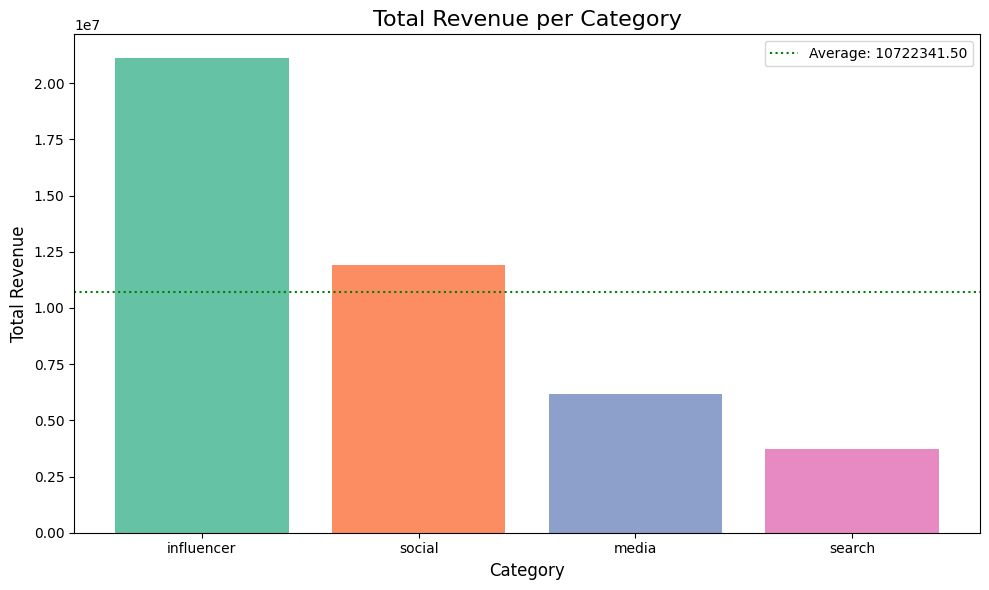

In [70]:
# Data preparation
DR = DF.groupby('category')['revenue'].sum()
DR = DR.sort_values(ascending=False)
avg_r = DR.mean() 

# Pallette
categories = DR.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(DR.index, DR.values, color=[category_colors[category] for category in DR.index])
plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Revenue per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


Pada visualisasi sebelumnya, Click terbanyak dimiliki oleh `social, influencer, media, dan search engine`. Maka pertanyaannya adalah apakah orang yang melakukan klik pasti melakukan pembelian dan berpengaruh pada revenue? 

Visualisasi diatas menunjukkan pendapatan yang paling besar adalah ketika menggunakan jasa influencer, dan yang paling rendah yaitu ads dengan search engine. Garis putus-putus menunjukkan rata-rata dari keseluruhan revenue, kedua kategori yang termasuk diatas rata-rata adalah influencer (instagram dan youtube blogger), dan social media (instagram dan facebook). 

Maka dapat disimpulan jika ingin `meningkatkan klik dan mengenalkan brand, kategori social media adalah yang paling cocok`. Sementara `influencer dapat mendorong lebih banyak penjualan` produk sehingga berdampak pada revenue.

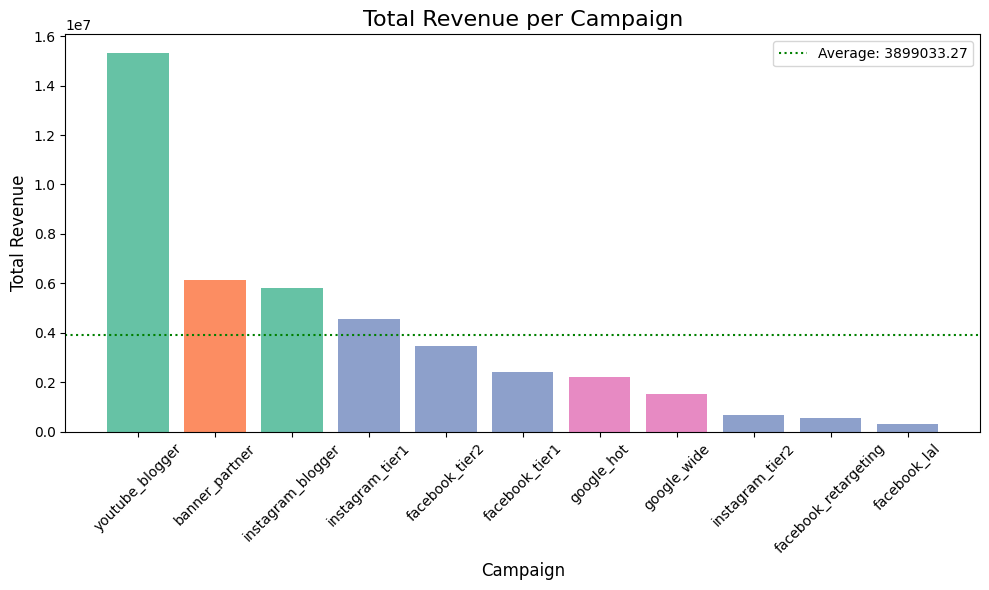

In [71]:
# Data preparation
DCN = DF.groupby('campaign_name')[['revenue', 'category']].sum()
DCN = DCN.sort_values(by='revenue', ascending=False)
avg_r = DCN['revenue'].mean()
categories = DCN['category'].unique()


# Pallette
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}
DCN['color'] = DCN['category'].map(category_colors)

# Pallette
categories = df_click.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))  # Ensure same palette
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(DCN.index, DCN['revenue'], color=DCN['color'])

plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Revenue per Campaign', fontsize=16)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


Bar chart diatas merupakan breakdown campaign per kategorinya. diketahui per kategori, sumbangan revenue terbesar adalah dari Influencer, Social, Media, dan yang terakhir Search engine. Namun apakah ada salah satu sub kategori (campaign) yang mendominasi sehingga mendongkrak revenue kategorinnya? maka digambarkan pada visuaslisasi diatas.

- Kategori Influencer, baik youtube maupun instagram blogger memiliki kontribusi yang baik dan diatas rata-rata keseluruhan. Artinya promosi yang dilakukan dengan bantuan influencer memiliki kontribusi yang nyata dan berdampak pada revenue. 
- Kategori Social, angka revenue yang cukup baik ditunjukkan oleh campaign instagram tier 1, facebook tier 2 dan facebook tier 1. Sementara untuk campaign yang menghasilkan revenue yang rendah yaitu instagram tier 2, facebook retargeteing dan facebook lal. Social media memiliki campaign yang paling banyak, maka perlu dipertimbangkan apakah marketing perlu melanjutkan beberapa campaign saja dengan memangkas lainnya dan meningkatkan budget.

### Cost

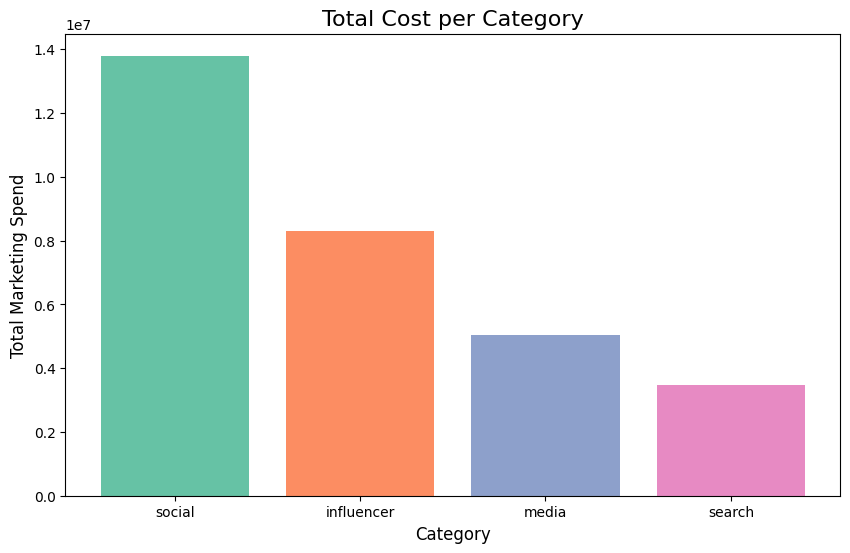

In [72]:
# Data prepare
DR = DF.groupby("category")[["mark_spent"]].sum().reset_index()
DR = DR.sort_values('mark_spent', ascending=False)

# Chart

# Pallette
categories = DR.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))  # Ensure same palette
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

plt.figure(figsize=(10, 6))
plt.bar(DR['category'], DR['mark_spent'], color=category_colors.values())
plt.title('Total Cost per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Marketing Spend', fontsize=12)

plt.show()

Bar chart menunjukkan iklan pada platform social media memakan biaya yang paling tinggi, disusul oleh influencer, media, lalu kategori yang paling kecil biayanya yaitu search engine.

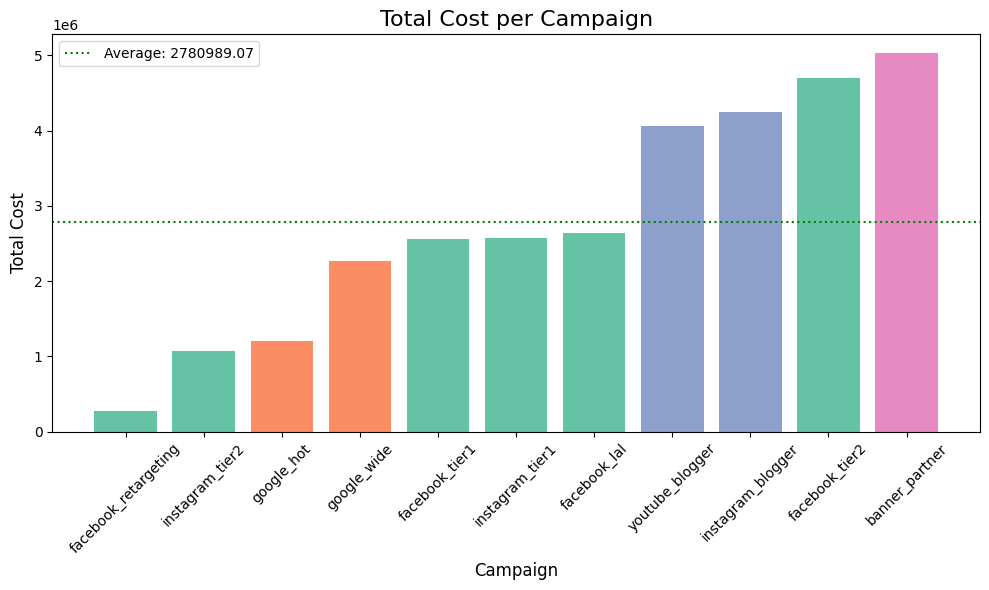

In [73]:
# Data preparation
DS = DF.groupby('campaign_name')[['mark_spent', 'category']].sum()
DS = DS.sort_values(by='mark_spent')
avg_r = DS['mark_spent'].mean()
categories = DS['category'].unique()

# Pallette
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}
DS['color'] = DS['category'].map(category_colors)

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(DS.index, DS['mark_spent'], color=DS['color'])

plt.axhline(y=avg_r, color='green', linestyle=':', label=f'Average: {avg_r:.2f}')
plt.title('Total Cost per Campaign', fontsize=16)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Rasio

#### Cost per Lead

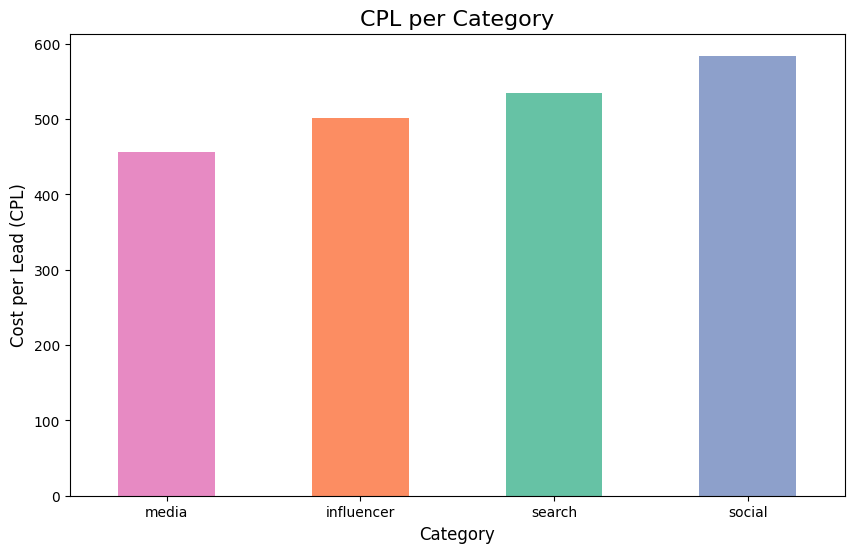

In [74]:
# Data prepare
DF['CPL'] = DF['mark_spent'] / DF['leads']
DF['CPL'] = DF['CPL'].replace([np.inf, -np.inf], np.nan)  # jika ada lead 0 maka akan menjadi infinite, maka diubah menjadi NaN

cpl_per_category = DF.groupby('category')['CPL'].mean()
cpl_per_category = cpl_per_category.sort_values()

# Chart
plt.figure(figsize=(10, 6))

categories = cpl_per_category.index
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

cpl_per_category.plot(kind='bar', color=[category_colors[category] for category in df_click.index])
plt.title('CPL per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=0)
plt.ylabel('Cost per Lead (CPL)', fontsize=12)

plt.show()

Cost per Lead menunjukkan berapa cost yang dibutuhkan untuk menghasilkan 1 lead. Semakin kecil angka CPL, menunjukkan semakin kecil cost yang dibutuhkan untuk menghasilkan lead. Dari visualisasi diatas menunjukkan campaign yang paling efisien dalam menghasilkan lead adalah Media, Influencer, Search Engine, lalu Social Media. Ini merupakan gambaran yang sifatnya agregasi, artinya bisa jadi salah satu campaign berpengaruh cukup besar saat penentuan CPL. Maka perlu ditelusuri lagi hingga per jenis campaign untuk mengetahui campaign mana, dalam kategori mana, yang lebih efisien.

<Figure size 1400x600 with 0 Axes>

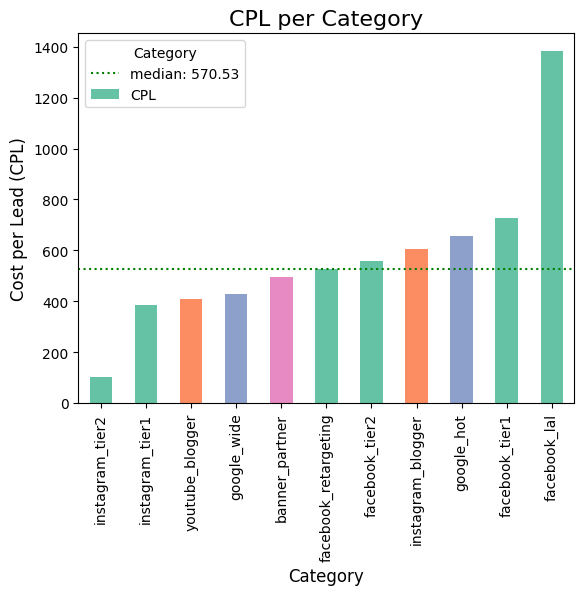

In [75]:
DF_grouped = DF.groupby('campaign_name').agg({
    'mark_spent': 'sum',
    'leads': 'sum',
    'category': 'first'  # Pilih kategori pertama dalam setiap grup
}).reset_index()
DF_grouped['CPL'] = DF_grouped['mark_spent'] / DF_grouped['leads']
DF_grouped = DF_grouped.sort_values(by='CPL')

# Chart
plt.figure(figsize=(14, 6))

# Mengambil kategori unik
categories = DF_grouped['category'].unique()

# Membuat palet warna berdasarkan kategori
color_palette = sns.color_palette("Set2", n_colors=len(categories))
category_colors = {category: color_palette[i] for i, category in enumerate(categories)}

# Membuat bar plot dengan warna sesuai kategori
DF_grouped.plot(kind='bar', x='campaign_name', y='CPL', color=[category_colors[category] for category in DF_grouped['category']])

# Menambahkan judul dan label
plt.title('CPL per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.axhline(y=DF_grouped['CPL'].median(), color='green', linestyle=':', label=f'median: {DF_grouped["CPL"].mean():.2f}')
plt.xticks(rotation=90)
plt.ylabel('Cost per Lead (CPL)', fontsize=12)
plt.legend(title='Category')

# Menampilkan chart
plt.show()

Cost per lead menggambarkan seberapa banyak biaya yang dikeluarkan untuk mendapatkan satu lead (prospek atau calon pelanggan). Secara umum, nilai CPL yang lebih rendah dianggap lebih baik, karena menunjukkan bahwa kamu menghabiskan lebih sedikit uang untuk mendapatkan satu lead.

Garis putus-putus menandakan median yang menjadi nilai tengah sebagai acuan data. Facebook lal merupakan campaign yang paling mahal costnya untuk menghasilkan lead, diikuti oleh fb tier 1 dan google hot sebagai 3 termahal penggunaan cost untuk menghasilkan lead. Hal ini dapat menjadi pertimbangan kelak, saluran promosi apa yang tepat untuk menghasilkan lead dengan efisien.

#### Cost to Revenue

In [76]:
total_revenue = DF['revenue'].sum()
total_spent = DF['mark_spent'].sum()

Profit  = total_revenue - total_spent
rasio = total_spent / total_revenue

# Menampilkan hasil
print("Total Revenue: ", total_revenue)
print("Total Spent: ", total_spent)
print("Profit : ", Profit )
print("Total Rasio Spent to Revenue: ", rasio)

grouped_df = DF.groupby('campaign_name').agg(
    total_mark_spent=('mark_spent', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

grouped_df['Spent per Revenue'] = grouped_df['total_mark_spent'] / grouped_df['total_revenue']
grouped_df = grouped_df.sort_values('Spent per Revenue').reset_index(drop=True)

a = grouped_df['total_mark_spent'].sum()
b = grouped_df['total_revenue'].sum()
grouped_df

Total Revenue:  42889366.0
Total Spent:  30590879.82
Profit :  12298486.18
Total Rasio Spent to Revenue:  0.7132509214521847


,campaign_name,total_mark_spent,total_revenue,Spent per Revenue
0,youtube_blogger,4057936.51,15311433.0,0.265027
1,facebook_retargeting,266466.22,536919.0,0.496288
2,google_hot,1199998.76,2205747.0,0.544033
3,instagram_tier1,2565277.25,4544124.0,0.564526
4,instagram_blogger,4247367.57,5808454.0,0.731239
5,banner_partner,5026674.76,6152960.0,0.816952
6,facebook_tier1,2564793.48,2396412.0,1.070264
7,facebook_tier2,4693870.97,3463306.0,1.355315
8,google_wide,2260401.31,1499318.0,1.507620
9,instagram_tier2,1066153.75,670460.0,1.590182


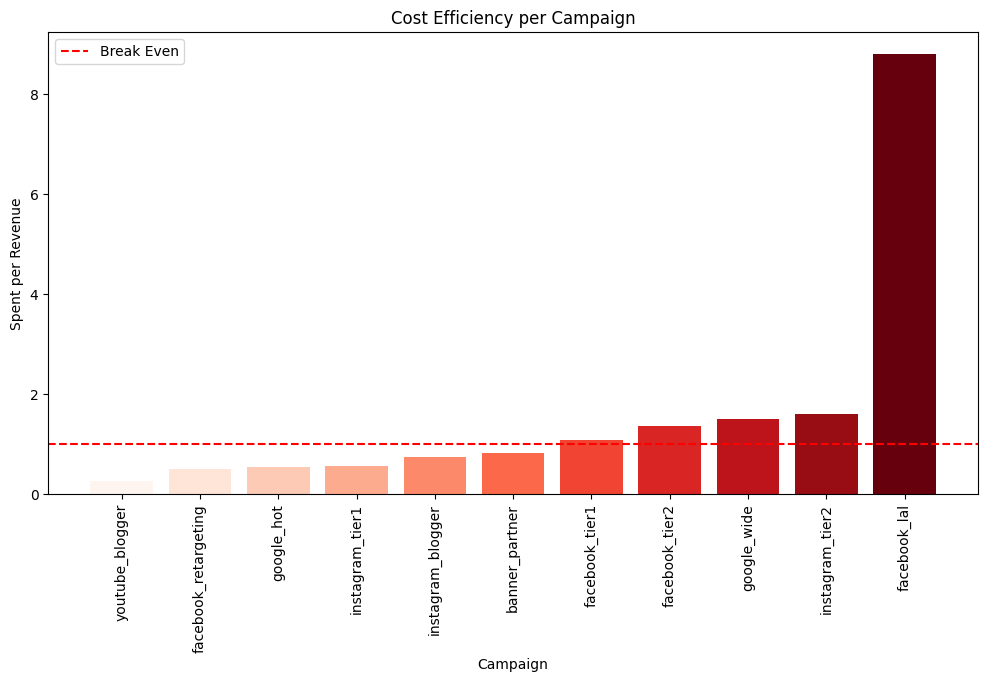

In [77]:
colors = plt.cm.Reds(np.linspace(0, 1, len(grouped_df)))

# Chart
plt.figure(figsize=(12,6))
plt.bar(grouped_df['campaign_name'], grouped_df['Spent per Revenue'],color=colors)

plt.title('Cost Efficiency per Campaign')
plt.xlabel('Campaign')
plt.ylabel('Spent per Revenue')
plt.xticks(rotation=90)
plt.axhline(y=1, color='r', linestyle='--')
plt.legend(['Break Even'])

# Menampilkan chart
plt.show()

Nilai Cost to Revenue menunjukkan biaya pemasaran yang dikeluarkan untuk setiap unit pendapatan yang dihasilkan, sehingga semakin kecil nilai Cost to Revenue maka semakin baik dan menunjukkan efisiensi campaign tersebut. Facebook lal memiliki nilai Cost to Revenue yang sangat besar, menandakan setiap $1 pendapatan yang dihasilkan, menggunakan $8 yang dikeluarkan untuk pemasaran. Maka dapat diartikan biaya campaign facebook lal 8x lebih besar daripada keuntungannya. Baiknya cost to revenue berada dibawah 1 (menandakan break even), maka dari visualisasi diatas, fb tier 1, fb tier 2, google wide, ig tier 2 dan facebook lal tidak memenuhi kondisi yang baik. 

## Korelasi biaya dan order

In [78]:
# tes normality dulu untuk kedua variabel diuji
print(f'p-value: {stats.normaltest(DF["mark_spent"]).pvalue}')
print(f'p-value: {stats.normaltest(DF["orders"]).pvalue}')

# Skewness
print(f"Skewness: {DF['mark_spent'].skew()}")
print(f"Skewness: {DF['orders'].skew()}")

# Kurtosis
print(f"Kurtosis: {DF['mark_spent'].kurtosis()}")
print(f"Kurtosis: {DF['orders'].kurtosis()}")


p-value: 2.377796545834737e-34
p-value: 8.310576505686648e-56
Skewness: 2.24123710500904
Skewness: 3.3837251196171843
Kurtosis: 5.50155454580627
Kurtosis: 16.88623130763034


Untuk mengetahui uji apa yang digunakan, maka terlebih dhulu dicek normalitas datanya. 
- Dari hasil normaltest, diketahui bahwa p-value < 0.05 maka data termasuk dalam kategori `tidak normal`.
- Skewness juga digunakan untuk mengetahui simetrikal distribusi. Hasil dari 2 variabel (2.24 dan 3.38) > 1 dan menunjukkan bahwa distribusinya `highly skewed` (sangat miring). Jika digambarkan grafinknya, maka ekor memanjang kekanan
- Nilai > 0 maka masuk kategori `Leptokurtic`, memiliki ekor yang tebal dan puncak yang lebih tinggi dibandingkan dengan distribusi normal. Hal ini menunjukkan bahwa data memiliki lebih banyak outlier.

## Inferensial Statistik
Keseluruhan data ingin digunakan untuk menunjukkan keaslian hasil campaign tanpa ada modifikasi data. Metode yang digunakan adalah `Spearman` karena data tidak normal dan skew, dimana metode ini tidak mengasumsikan distribusi tertentu untuk data dan sesuai untuk variabel yang mungkin tidak memiliki hubungan linier. Uji ini lebih stabil terhadap data yang memiliki banyak outlier atau tingkat skewness tinggi.

**Hipotesis**
- Hipotesis Nol (H₀): Tidak ada hubungan signifikan antara biaya yang dikeluarkan (mark_spent) dan jumlah pesanan (orders). Artinya, perubahan pada biaya yang dikeluarkan tidak memengaruhi jumlah pesanan.
- Hipotesis Alternatif (H₁): Ada hubungan signifikan antara biaya yang dikeluarkan (mark_spent) dan jumlah pesanan (orders). Artinya, perubahan pada biaya yang dikeluarkan memengaruhi jumlah pesanan.

In [79]:
corr_rho, pval_s = stats.spearmanr(DF['mark_spent'], DF['orders'])
print(f"r-correlation: {corr_rho:.2f}, p-value: {pval_s}")

r-correlation: 0.97, p-value: 6.921768534437307e-184


Korelasi Spearman sebesar 0.97 menunjukkan adanya hubungan yang sangat kuat dan positif antara kedua variabel (biaya yang dikeluarkan dan jumlah pesanan). Artinya, semakin tinggi biaya yang dikeluarkan (misalnya untuk iklan), semakin banyak jumlah pesanan yang diperoleh.

P-value yang sangat kecil (lebih kecil dari 0.05) menunjukkan bahwa hubungan yang ditemukan tidak mungkin terjadi secara kebetulan. Dalam hal ini,  hipotesis nol (H₀) dapat ditolak dan hipotesis alternatif (H₁) diterima, sehingga dapat dinyatakan bahwa `ada hubungan yang signifikan antara biaya yang dikeluarkan dan jumlah pesanan`.

# Kesimpulan & Rekomendasi

## Kesimpulan
Berikut adalah kesimpulan dari data yang diolah:

**Revenue:**
Rata-rata pendapatan perusahaan adalah Rp139.251,18. Nilai tengahnya (median) adalah Rp38.917. Pendapatan yang paling sering muncul adalah 0 (nilai minimal), sementara nilai maksimum yang dicapai adalah Rp2.812.520. Ini menunjukkan adanya variasi yang besar dalam pendapatan, dengan sejumlah data yang mungkin tidak stabil atau sangat rendah/tinggi.

**Promosi dan Impressions:**
Persentase promosi terbesar pada kategori social media adalah 54,5%, dengan distribusi rata untuk setiap nama kampanye. Data impressions tertinggi tercatat pada 18 Februari 2021. Klik tertinggi pada iklan terjadi pada 20 Februari 2021.

**Efektivitas Iklan:**
Pendapatan tertinggi diperoleh dari penggunaan jasa influencer, sementara iklan dengan search engine menghasilkan pendapatan terendah. Bar chart menunjukkan bahwa biaya iklan pada platform social media adalah yang tertinggi, diikuti oleh influencer, media, dan search engine sebagai kategori dengan biaya terendah.

**Distribusi Data:**
Data tidak berdistribusi normal dan Skewness menunjukkan distribusi data sangat miring (highly skewed), diagram kurtosis juga menunjukkan sifat leptokurtic yang menunjukkan adanya banyak outlier.

**Inferensial Statistik**
Keseluruhan data ingin digunakan untuk menunjukkan keaslian hasil campaign. Koefisien Korelasi Spearman (r): 0,97, yang menunjukkan adanya korelasi yang sangat kuat dan positif antara biaya yang dikeluarkan dan jumlah pesanan.P-Value: Lebih kecil dari 0,05 (5%), yang berarti H0 ditolak dan H1 diterima. Ini menunjukkan bahwa hubungan yang ditemukan antara biaya iklan dan jumlah pesanan adalah signifikan dan bukan kebetulan. 

Secara keseluruhan, kesimpulannya data pendapatan perusahaan sangat bervariasi, dan efektivitas berbagai saluran promosi menunjukkan perbedaan yang signifikan. Distribusi mengindikasikan data tidak normal dan memiliki karakteristik distribusi yang sangat miring dengan banyak outlier. hasil analisis menunjukkan bahwa budget iklan berhubungan erat dengan peningkatan jumlah pesanan, memberikan indikasi bahwa alokasi anggaran iklan yang lebih tinggi dapat meningkatkan hasil penjualan.



## Rekomendasi
- Identifikasi lebih dalam saluran promosi yang paling efektif dan kurang efektif dalam hal klik dan konversi.
- Social Media memiliki budget promosi terbesar, pertimbangkan untuk memastikan targeting dengan tepat agar efektif.
- Kategori influencer menghasilkan revenue tertinggi, maka bisa pertimbangkan untuk memperluas kolaborasi dengan influencer yang memiliki audiens relevan.
- Perhatikan timing Iklan pada hari dan waktu dengan traffic tinggi atau saat audiens lebih aktif.
- Monitoring dan Evaluasi bulanan, lakukan tindakan korektif yang diperlukan untuk memastikan target dapat tercapai sebelum akhir periode.
- Kenaikan budget campaign sejalan dengan kenaikan jumlah order, masih bisa dilakukan seiring dengan monitoring berkala.

# Save to CSV

In [80]:
DF.to_csv('Marketing.csv', index=False)